# Week 2 - 9/14/2026: Dataset Exploration

Goal: get familiar with the raw dataset before any cleaning or modeling.

This notebook covers:
- Loading the raw data
- Variable definitions and data types
- General dataset stats (row/column counts, missing values, etc.)

## Setup

We used `pathlib` to build the path to the raw data folder relative to this notebook.
so the notebook works for every team member regardless of where they
cloned the repo on their own machine.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
      
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

DATA_FILE = RAW_DATA_DIR / "big_startup_secsees_dataset.csv"

## Load the dataset

In [8]:
df = pd.read_csv(DATA_FILE)

df.head()

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,1/5/2015,1/5/2015
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,9/4/2014,3/1/2014,10/14/2014
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,1/30/2014,1/30/2014
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,1/1/2007,3/19/2008,3/19/2008
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,1/1/2010,7/24/2014,7/24/2014


## General dataset stats

Row count, column count, and column names.

In [9]:
n_rows, n_cols = df.shape

print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_cols}")
print(f"Column names:{list(df.columns)}")

Number of rows: 66368
Number of columns: 14
Column names:['permalink', 'name', 'homepage_url', 'category_list', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'first_funding_at', 'last_funding_at']


## Variable definitions and data types

For each column: its data type, number of missing values, and number of unique values.
This gives a quick sense of which variables are numeric, categorical, or dates,
and how complete each one is.

In [10]:
variable_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_values": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2),
    "unique_values": df.nunique(),
})

variable_summary

,dtype,missing_values,missing_pct,unique_values
permalink,object,0,0.00,66368
name,object,1,0.00,66102
homepage_url,object,5058,7.62,61191
category_list,object,3148,4.74,27296
funding_total_usd,object,0,0.00,18896
status,object,0,0.00,4
country_code,object,6958,10.48,137
state_code,object,8547,12.88,311
region,object,8030,12.10,1092
city,object,8028,12.10,5111


## Summary statistics for numeric columns

In [11]:
df.describe()

,funding_rounds
count,66368.000000
mean,1.732522
std,1.360251
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,19.000000


## Visualizing missing data

A simple bar chart of missing value counts per column, using only matplotlib
so it stays easy to read and modify.

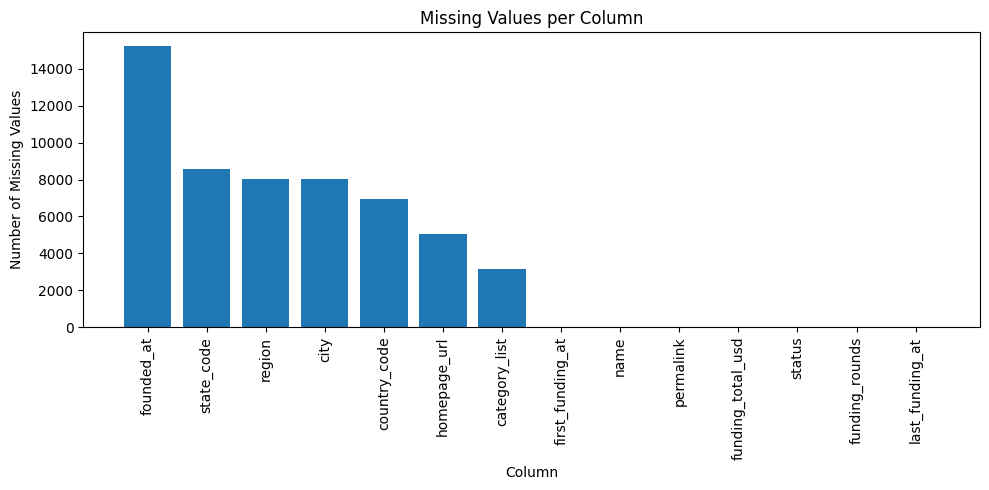

In [12]:
missing_counts = df.isnull().sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(missing_counts.index, missing_counts.values)

ax.set_title("Missing Values per Column")
ax.set_xlabel("Column")
ax.set_ylabel("Number of Missing Values")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Target Variable

Our target variable is `status`, which categorizes each startup's outcome as one of four values: operating, acquired, closed, or ipo (i.e., went public).

We chose `status` as the target because our project's goal is to predict startup outcomes beyond simply looking at total funding raised. A total-funding-only view treats two startups that raised the same amount over very different timelines as equivalent, even though the path each company took to reach that funding level tells a very different story. By using `status` as the outcome we're predicting, we can incorporate funding velocity and timing patterns (how quickly rounds occurred relative to founding and to each other) as predictors, since those signals say more about a company's trajectory than the funding total alone.

In [13]:
# Count and percentage breakdown of each status category
status_counts = df['status'].value_counts()
status_pct = (df['status'].value_counts(normalize=True) * 100).round(2)

pd.DataFrame({'count': status_counts, 'percent': status_pct})

,count,percent
status,,
operating,53034,79.91
closed,6238,9.40
acquired,5549,8.36
ipo,1547,2.33


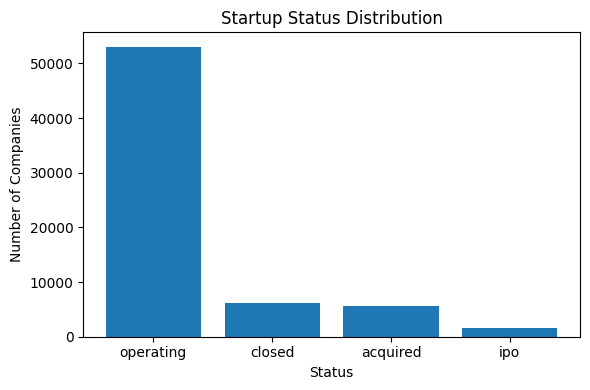

In [14]:
# Bar chart showing the distributionof startups across each status category
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(status_counts.index, status_counts.values)

ax.set_title("Startup Status Distribution")
ax.set_xlabel("Status")
ax.set_ylabel("Number of Companies")
plt.tight_layout()
plt.show()